In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import japanize_matplotlib
import matplotlib.dates as mdates
import pymc as pm
import arviz as az
import arviz_plots as azp
import pytensor.tensor as pt


In [2]:
#地震データの取得
url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
params = {
    "format": "geojson",
    "starttime": "2024-01-01",
    "endtime": "2024-03-01",
    "minlatitude": 34,
    "maxlatitude": 39,
    "minlongitude": 135,
    "maxlongitude": 140,
    "minmagnitude": 2.5,
}

response = requests.get(url, params=params)
data = response.json()

records = []
for feature in data["features"]:
    props = feature["properties"]
    records.append({
        "time": pd.to_datetime(props["time"], unit="ms"),
        "mag": props["mag"],
        "depth": feature["geometry"]["coordinates"][2],
        "place": props["place"],
    })

df = pd.DataFrame(records).sort_values("time").reset_index(drop=True)
print(df.shape)
df.to_csv("../data/noto_earthquakes_2024.csv", index=False)

(141, 4)


In [3]:
df = pd.read_csv("../data/noto_earthquakes_2024.csv")
df.head()

,time,mag,depth,place
0,2024-01-01 07:06:05.477,5.8,10.0,"42 km NE of Anamizu, Japan"
1,2024-01-01 07:10:09.476,7.5,10.0,"2024 Noto Peninsula, Japan Earthquake"
2,2024-01-01 07:18:41.584,6.2,10.0,"8 km SW of Anamizu, Japan"
3,2024-01-01 07:27:28.747,4.6,10.0,"33 km ENE of Anamizu, Japan"
4,2024-01-01 07:28:15.144,4.6,10.0,"15 km NNW of Anamizu, Japan"


In [4]:
#EDA
print(df["mag"].describe())

#本震を特定し、経過時間に変換
df["time"] = pd.to_datetime(df["time"])
mainshock_time = df.loc[df["mag"].idxmax(), "time"]
print("本震時刻:", mainshock_time, "M:", df["mag"].max())

df["days_since_mainshock"] = (df["time"] - mainshock_time).dt.total_seconds() / 86400
print(df["days_since_mainshock"].describe())

count    141.000000
mean       4.544681
std        0.469715
min        3.800000
25%        4.300000
50%        4.400000
75%        4.700000
max        7.500000
Name: mag, dtype: float64
本震時刻: 2024-01-01 07:10:09.476000 M: 7.5
count    141.000000
mean       8.652777
std       14.209586
min       -0.002824
25%        0.104055
50%        1.111236
75%       10.572440
max       58.003015
Name: days_since_mainshock, dtype: float64


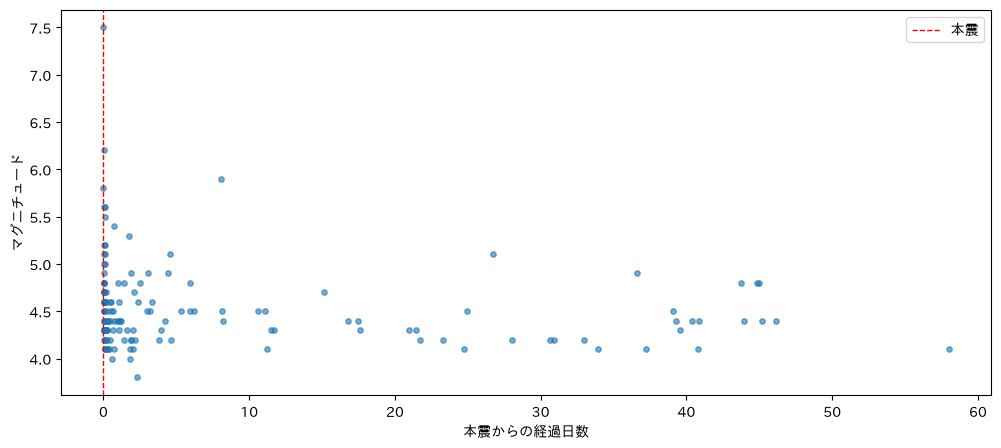

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(df["days_since_mainshock"], df["mag"], s=15, alpha=0.6)
ax.axvline(0, color="red", ls="--", lw=1, label="本震")
ax.set_xlabel("本震からの経過日数")
ax.set_ylabel("マグニチュード")
ax.legend()
plt.savefig("../img/eda_mag_vs_time.png", dpi=100)

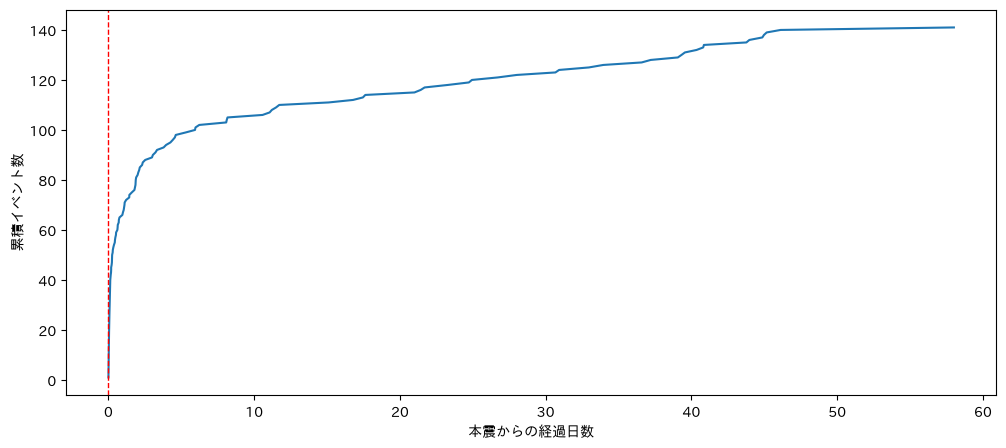

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["days_since_mainshock"], np.arange(1, len(df)+1))
ax.axvline(0, color="red", ls="--", lw=1)
ax.set_xlabel("本震からの経過日数")
ax.set_ylabel("累積イベント数")
plt.savefig("../img/eda_cumulative.png", dpi=100)

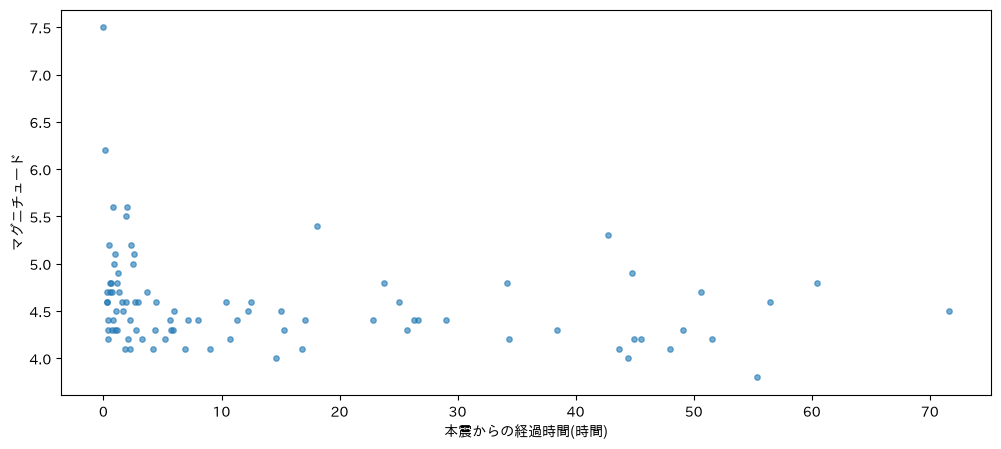

In [7]:
recent = df[(df["days_since_mainshock"] >= 0) & (df["days_since_mainshock"] < 3)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(recent["days_since_mainshock"]*24, recent["mag"], s=15, alpha=0.6)
ax.set_xlabel("本震からの経過時間(時間)")
ax.set_ylabel("マグニチュード")
plt.savefig("../img/eda_first72h.png", dpi=100)

最初の72時間のグラフを保存しました: earthquake_hourly_first72h.png


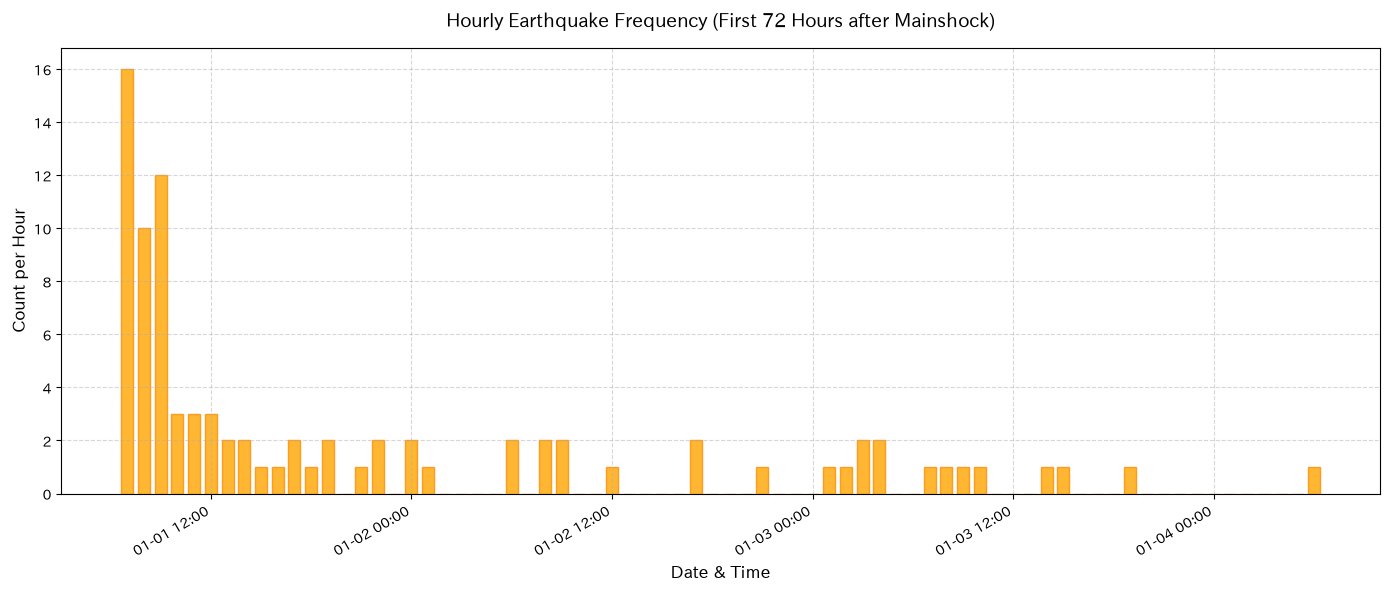

In [ ]:
# 1. データの読み込みと前処理
df = pd.read_csv("noto_earthquakes_2024.csv")
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

# 2. 最大マグニチュード（本震）の時刻を特定し、そこから3日間にデータを絞る
mainshock_time = df.loc[df["mag"].idxmax(), "time"]
end_time = mainshock_time + pd.Timedelta(days=3)
df_filtered = df[(df["time"] >= mainshock_time) & (df["time"] <= end_time)]

# 3. 1時間ごとにリサンプリングして件数を集計
df_hourly_short = df_filtered.set_index("time").resample("1h").size().reset_index(name="count")

# 4. グラフの描画
fig, ax = plt.subplots(figsize=(14, 6))
# width=0.03日（約43分）で棒同士が綺麗に並ぶように調整
ax.bar(df_hourly_short["time"], df_hourly_short["count"], width=0.03, color="orange", edgecolor="darkorange", alpha=0.8)

# グラフのレイアウト調整
ax.set_title("Hourly Earthquake Frequency (First 72 Hours after Mainshock)", fontsize=14, pad=15)
ax.set_xlabel("Date & Time", fontsize=12)
ax.set_ylabel("Count per Hour", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

# X軸の目盛りフォーマット（月-日 時間:分）
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig("../img/earthquake_hourly_first72h.png", dpi=150)
print("最初の72時間のグラフを保存しました: earthquake_hourly_first72h.png")

In [9]:
mainshock_time = df.loc[df["mag"].idxmax(), "time"]
df["t"] = (df["time"] - mainshock_time).dt.total_seconds() / 86400

t_obs = df["t"].values
n = len(t_obs)
T_end = t_obs.max()

with pm.Model() as earthquake_model:
    mu = pm.Exponential("mu", lam=1/0.67)
    beta = pm.Exponential("beta", lam=1/2)
    kappa = pm.Exponential("kappa", lam=1/15)

    t = pt.as_tensor_variable(t_obs)

    dt = t[:, None] - t[None,:]
    mask = dt > 0

    excitation = pt.switch(mask, kappa * pt.exp(-beta * dt), 0.0)

    lambda_t = mu + excitation.sum(axis=1)
    pm.Deterministic("lambda_t", lambda_t)

    log_lik_sum = pt.sum(pt.log(lambda_t))

    integral_excitation = (kappa / beta) * ( 1 - pt.exp(-beta * (T_end - t)))
    total_integral = mu * T_end + pt.sum(integral_excitation)

    loglike = log_lik_sum - total_integral
    pm.Potential("loglike", loglike)
    
    

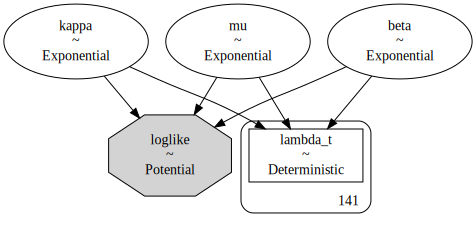

In [10]:
pm.model_to_graphviz(earthquake_model)

In [11]:
with earthquake_model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["beta", "mu", "kappa", "lambda_t"],
        random_seed=42
    )

lambda_t_prior = prior.prior["lambda_t"].values

print("lambda_t の事前分布 統計:")
print("  最小値:", lambda_t_prior.min())
print("  最大値:", lambda_t_prior.max())
print("  中央値:", np.median(lambda_t_prior))
print("  99percentile:", np.percentile(lambda_t_prior, 99))


/tmp/ipykernel_117096/2628087350.py:2: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior = pm.sample_prior_predictive(
Sampling: [beta, kappa, mu]


lambda_t の事前分布 統計:
  最小値: 0.007374706718426495
  最大値: 5880.431745892047
  中央値: 84.34403229204494
  99percentile: 2071.496525372525


In [12]:
for name in ["mu", "beta", "kappa"]:
    vals = prior.prior[name].values.flatten()
    print(f"{name}: mean={vals.mean():.2f}, min={vals.min():.3f}, max={vals.max():.2f}")

mu: mean=0.67, min=0.007, max=5.56
beta: mean=2.05, min=0.001, max=14.04
kappa: mean=15.10, min=0.050, max=88.66


In [13]:
with pm.Model() as earthquake_model:
    mu = pm.Exponential("mu", lam=1/0.67)
    beta = pm.Gamma("beta", alpha=3, beta=1.5)
    kappa = pm.Exponential("kappa", lam=1/15)

    t = pt.as_tensor_variable(t_obs)

    dt = t[:, None] - t[None,:]
    mask = dt > 0

    excitation = pt.switch(mask, kappa * pt.exp(-beta * dt), 0.0)

    lambda_t = mu + excitation.sum(axis=1)
    pm.Deterministic("lambda_t", lambda_t)

    log_lik_sum = pt.sum(pt.log(lambda_t))

    integral_excitation = (kappa / beta) * ( 1 - pt.exp(-beta * (T_end - t)))
    total_integral = mu * T_end + pt.sum(integral_excitation)

    loglike = log_lik_sum - total_integral
    pm.Potential("loglike", loglike)
    
    

In [ ]:
pm.model_to_graphviz(earthquake_model)

In [14]:
with earthquake_model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["beta", "mu", "kappa", "lambda_t"],
        random_seed=42
    )

lambda_t_prior = prior.prior["lambda_t"].values

print("lambda_t の事前分布 統計:")
print("  最小値:", lambda_t_prior.min())
print("  最大値:", lambda_t_prior.max())
print("  中央値:", np.median(lambda_t_prior))
print("  99percentile:", np.percentile(lambda_t_prior, 99))


/tmp/ipykernel_117096/2628087350.py:2: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior = pm.sample_prior_predictive(
Sampling: [beta, kappa, mu]


lambda_t の事前分布 統計:
  最小値: 0.007374706718426495
  最大値: 3639.7032973069354
  中央値: 64.31385534180482
  99percentile: 1610.2226510458245


In [15]:
for name in ["mu", "beta", "kappa"]:
    vals = prior.prior[name].values.flatten()
    print(f"{name}: mean={vals.mean():.2f}, min={vals.min():.3f}, max={vals.max():.2f}")

mu: mean=0.67, min=0.007, max=5.56
beta: mean=2.01, min=0.082, max=7.95
kappa: mean=15.10, min=0.050, max=88.66


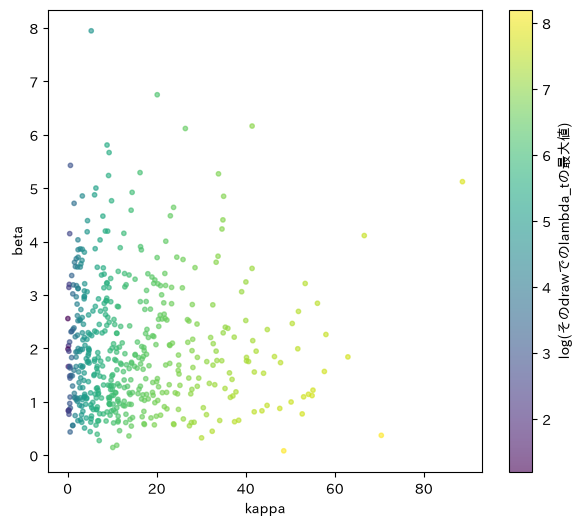

In [17]:
lambda_max_per_drew = lambda_t_prior.max(axis=2).flatten()
kappa_vals = prior.prior["kappa"].values.flatten()
beta_vals = prior.prior["beta"].values.flatten()

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(kappa_vals, beta_vals, c=np.log(lambda_max_per_drew+1), cmap="viridis", s=10, alpha=0.6)
plt.colorbar(sc, label="log(そのdrawでのlambda_tの最大値)")
ax.set_xlabel("kappa")
ax.set_ylabel("beta")
plt.savefig("../img/kappa_beta_diagnostic.png", dpi=100)

In [18]:
with pm.Model() as earthquake_model:
    mu = pm.Exponential("mu", lam=1/0.67)
    beta = pm.Gamma("beta", alpha=3, beta=1.5)
    kappa = pm.Gamma("kappa", alpha=3, beta=0.2)

    t = pt.as_tensor_variable(t_obs)

    dt = t[:, None] - t[None,:]
    mask = dt > 0

    excitation = pt.switch(mask, kappa * pt.exp(-beta * dt), 0.0)

    lambda_t = mu + excitation.sum(axis=1)
    pm.Deterministic("lambda_t", lambda_t)

    log_lik_sum = pt.sum(pt.log(lambda_t))

    integral_excitation = (kappa / beta) * ( 1 - pt.exp(-beta * (T_end - t)))
    total_integral = mu * T_end + pt.sum(integral_excitation)

    loglike = log_lik_sum - total_integral
    pm.Potential("loglike", loglike)
    
    

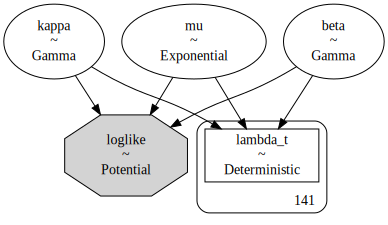

In [22]:
pm.model_to_graphviz(earthquake_model)

In [19]:
with earthquake_model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["beta", "mu", "kappa", "lambda_t"],
        random_seed=42
    )

lambda_t_prior = prior.prior["lambda_t"].values

print("lambda_t の事前分布 統計:")
print("  最小値:", lambda_t_prior.min())
print("  最大値:", lambda_t_prior.max())
print("  中央値:", np.median(lambda_t_prior))
print("  99percentile:", np.percentile(lambda_t_prior, 99))


/tmp/ipykernel_117096/2628087350.py:2: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior = pm.sample_prior_predictive(
Sampling: [beta, kappa, mu]


lambda_t の事前分布 統計:
  最小値: 0.007374706718426495
  最大値: 1841.6248888311227
  中央値: 91.90783334459178
  99percentile: 1038.552396703651


In [20]:
for name in ["mu", "beta", "kappa"]:
    vals = prior.prior[name].values.flatten()
    print(f"{name}: mean={vals.mean():.2f}, min={vals.min():.3f}, max={vals.max():.2f}")

mu: mean=0.67, min=0.007, max=5.56
beta: mean=2.01, min=0.082, max=7.95
kappa: mean=13.51, min=1.403, max=50.25


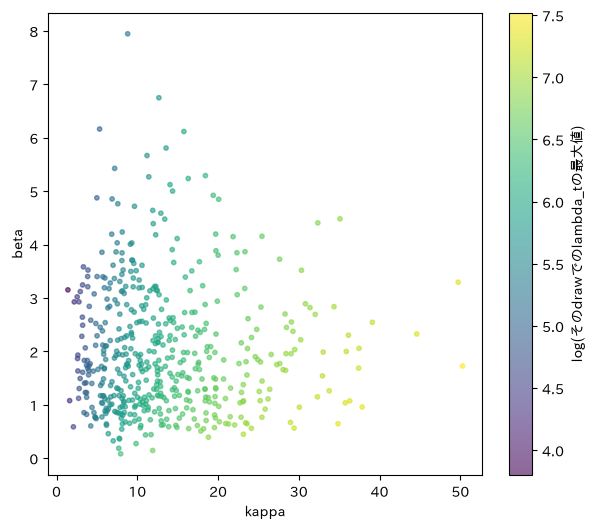

In [21]:
lambda_max_per_drew = lambda_t_prior.max(axis=2).flatten()
kappa_vals = prior.prior["kappa"].values.flatten()
beta_vals = prior.prior["beta"].values.flatten()

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(kappa_vals, beta_vals, c=np.log(lambda_max_per_drew+1), cmap="viridis", s=10, alpha=0.6)
plt.colorbar(sc, label="log(そのdrawでのlambda_tの最大値)")
ax.set_xlabel("kappa")
ax.set_ylabel("beta")
plt.savefig("../img/kappa_beta_diagnostic(beta~gamma).png", dpi=100)

In [30]:
with earthquake_model:
    idata = pm.sample(
        draws=2000, tune=2000, chains=4, cores=4,
        target_accept=0.9, nuts_sampler="numpyro",
        random_seed=42
    )
print("divergences:", int(idata.sample_stats["diverging"].sum()))
az.summary(idata,var_names=["mu", "beta", "kappa"])

NUTS[numpyro]: [mu, beta, kappa]
Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]

  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]


  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|                                                                                            | 0/4000 [00:01<?, ?it/s]

Running chain 2:   0%|                                                                                            | 0/4000 [00:01<?, ?it/s]


Running chain 1:   5%|████                                                                             | 200/4000 [00:

divergences: 53


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,0.625,0.124,0.44,0.83,3999,4148,1.00,0.0019,0.0014
beta,7.41,1.29,5.5,9.6,2819,3299,1.00,0.024,0.017
kappa,5.62,1.05,4.1,7.4,3026,3550,1.00,0.019,0.014


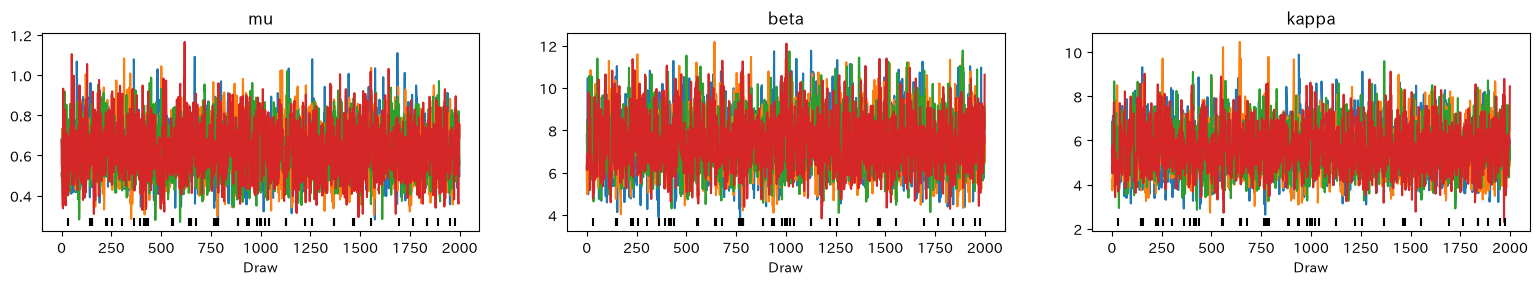

In [31]:
az.plot_trace(idata, var_names=["mu","beta", "kappa"])

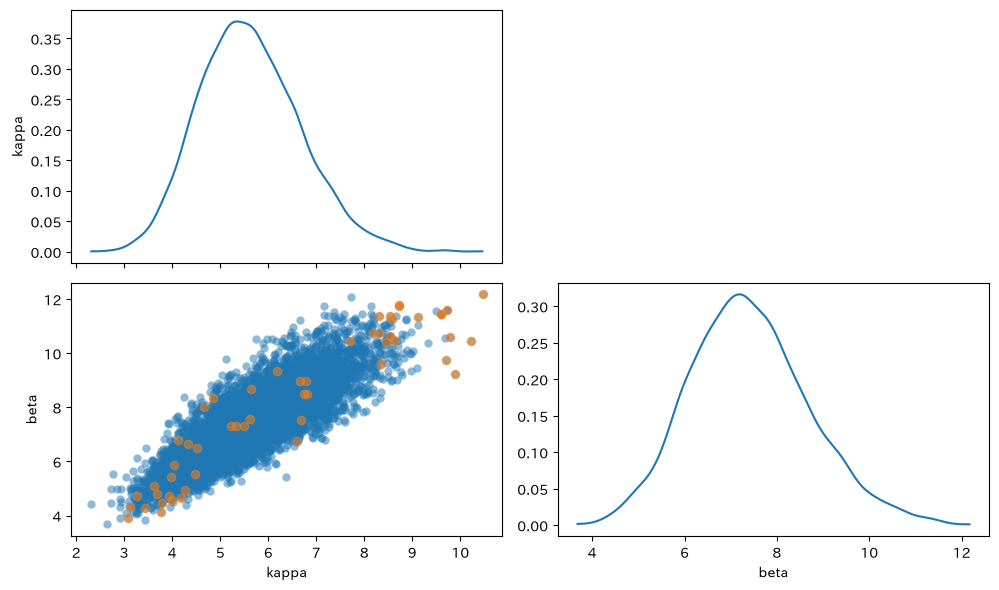

<Figure size 640x480 with 0 Axes>

In [34]:
azp.plot_pair(idata, var_names=["kappa", "beta"], visuals={"divergence":True}, figure_kwargs={"figsize":(10, 6)})
plt.tight_layout()
plt.show()
plt.savefig("../img/divergence_check.png", dpi=100)



In [35]:
#対症療法target_accept=0.95
with earthquake_model:
    idata = pm.sample(
        draws=2000, tune=2000, chains=4, cores=4,
        target_accept=0.95, nuts_sampler="numpyro",
        random_seed=42
    )
print("divergences:", int(idata.sample_stats["diverging"].sum()))
az.summary(idata,var_names=["mu", "beta", "kappa"])

NUTS[numpyro]: [mu, beta, kappa]
Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]

  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]


  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|                                                                                            | 0/4000 [00:01<?, ?it/s]

Running chain 2:   0%|                                                                                            | 0/4000 [00:01<?, ?it/s]


Running chain 3:   0%|                                                                                            | 0/

divergences: 49


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,0.624,0.126,0.43,0.83,3575,3418,1.00,0.0021,0.0015
beta,7.41,1.29,5.5,9.6,2880,3699,1.00,0.024,0.017
kappa,5.63,1.06,4.1,7.5,2971,3592,1.00,0.02,0.015


In [36]:
with pm.Model() as earthquake_model:
    mu = pm.Exponential("mu", lam=1/0.67)
    beta = pm.Gamma("beta", alpha=3, beta=1.5)
    M = pm.Exponential("M", lam=1/0.3)
    
    kappa = pm.Deterministic("kappa", M * beta)

    t = pt.as_tensor_variable(t_obs)

    dt = t[:, None] - t[None,:]
    mask = dt > 0

    excitation = pt.switch(mask, kappa * pt.exp(-beta * dt), 0.0)

    lambda_t = mu + excitation.sum(axis=1)
    pm.Deterministic("lambda_t", lambda_t)

    log_lik_sum = pt.sum(pt.log(lambda_t))

    integral_excitation = (kappa / beta) * ( 1 - pt.exp(-beta * (T_end - t)))
    total_integral = mu * T_end + pt.sum(integral_excitation)

    loglike = log_lik_sum - total_integral
    pm.Potential("loglike", loglike)
    
    

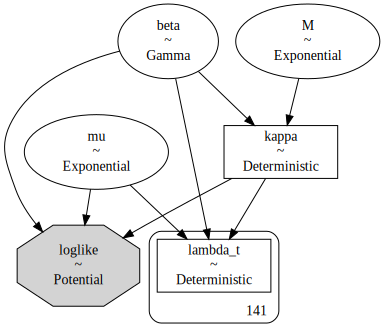

In [38]:
pm.model_to_graphviz(earthquake_model)

In [41]:
with earthquake_model:
    idata = pm.sample(
        draws=2000, tune=2000, chains=4, cores=4,
        target_accept=0.90, nuts_sampler="numpyro",
        random_seed=42
    )
print("divergences:", int(idata.sample_stats["diverging"].sum()))
az.summary(idata,var_names=["mu", "beta", "kappa", "M"])

NUTS[numpyro]: [mu, beta, M]
Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]

  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]


  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|                                                                                            | 0/4000 [00:01<?, ?it/s]

Running chain 2:   0%|                                                                                            | 0/4000 [00:01<?, ?it/s]


Running chain 3:   0%|                                                                                            | 0/4000

divergences: 36


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,0.622,0.125,0.43,0.83,6382,4976,1.00,0.0015,0.0011
beta,7.04,1.24,5.2,9.1,5943,5536,1.00,0.016,0.012
kappa,5.2,0.99,3.7,6.9,6908,5762,1.00,0.012,0.0092
M,0.74,0.078,0.62,0.87,6651,5540,1.00,0.00095,0.00069


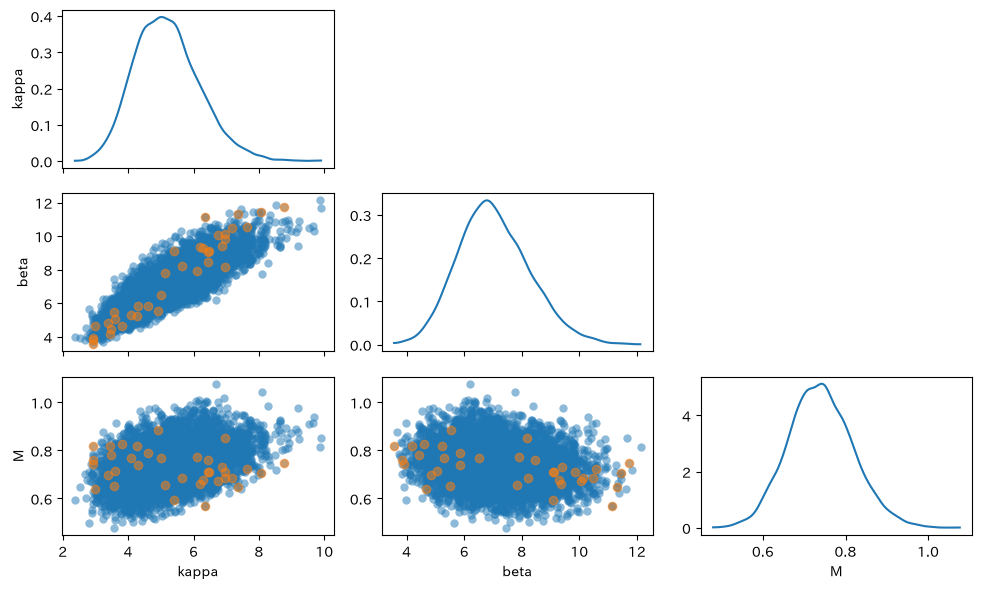

<Figure size 640x480 with 0 Axes>

In [43]:
azp.plot_pair(idata, var_names=["kappa", "beta","M"], visuals={"divergence":True}, figure_kwargs={"figsize":(10, 6)})
plt.tight_layout()
plt.show()
plt.savefig("../img/divergence_check(M*kappa).png", dpi=100)

# 能登半島地震(2024) 自己励起点過程(Hawkes/ETAS)モデル セッションサマリー

## 目的

これまでの離散時系列(SV, MSM)・横断データ(階層ベイズ)とは異なる第三のデータ構造として、**不規則な連続時間に発生するイベント**を扱う点過程モデリングに挑戦する。地震の「大きな地震の後は余震が連鎖的に起きやすい」という自己励起性を、Hawkes過程(地震学ではETAS: Epidemic-Type Aftershock Sequenceモデル)で捉える。

## データ

- USGS地震カタログAPI(`earthquake.usgs.gov/fdsnws/event/1/query`)から、能登半島周辺(北緯34-39°、東経135-140°)、2024年1月1日〜3月1日、M2.5以上の地震を取得
- n=141件、本震M7.5(2024-01-01 07:10 UTC)を含む、経過日数0〜58日
- **データ取得の紆余曲折**: サンドボックス環境の`web_fetch`ツールで`/query`エンドポイントへの任意パラメータでのアクセスが安定せず(`/count`エンドポイントは動作したが`/query`は"Internal fetch error"を繰り返した上、実際にはキャッシュされた例が返っている疑いもあった)、最終的にユーザー自身の環境で`requests`ライブラリを使い取得・アップロードする方式に切り替えた。

## モデル構造

$$\lambda(t) = \mu + \sum_{t_j<t}\kappa\, e^{-\beta(t-t_j)}$$

- $\mu$: 背景発生率(1日あたりの自然地震活動)
- $\kappa$: 1イベントが誘発する興奮の初期強度
- $\beta$: 興奮の減衰速度

**尤度の実装が、これまでのモデルと質的に異なる点**: 点過程の対数尤度

$$\log L = \sum_i\log\lambda(t_i) - \int_0^T\lambda(t)\,dt$$

は既製の確率分布(`pm.Normal`等)に対応しないため、MSMのforward algorithmと同様に`pm.Potential`で直接尤度を書く必要があった。積分項は指数減衰カーネルなら解析的に計算可能($\frac{\kappa}{\beta}(1-e^{-\beta(T-t_i)})$の全イベント総和)。

### ベクトル化の設計

$T\times T$(141×141)の時間差行列 `dt = t[:,None] - t[None,:]` を作り、`dt>0`のマスクで「自分より前に起きたイベントだけ」を抽出、`pt.switch`で条件付き計算を行うことで、`pytensor.scan`を使わずベクトル演算のみでモデルを構築できた。この設計はHawkes過程・自己励起点過程のPyMC実装における定石パターン。

## 事前分布のスケール決定: EDAからの逆算

これまでのセッション同様、事前分布のスケールをデータから逆算する手順を踏んだ:
- **$\mu$**: 余震が収まった後(30日目以降)の累積件数の傾き ≈ 0.678件/日 → `Exponential(lam=1/0.67)`
- **$\beta$**: 本震後1時間(18件/時)〜24時間(2.8件/時)の減衰速度から概算 → 当初$\beta\approx1$と見積もったが、実測の減衰速度(6.4倍/24時間)から逆算すると$\beta\approx1.9$の方が近く、$\beta\approx2$に修正
- **$\kappa$**: 本震直後の発生密度(1時間で18件等)から15前後と概算

## Prior predictive checkでの暴走とその修正(2段階)

初期設定で`lambda_t`の事前予測最大値が5880に達する暴走が発生。これまでのSV($\sigma_\eta^2/(1-\phi^2)$)、サメ($\mu^2/\alpha_{conc}$)と同型の病理: **$\beta\to0$のとき減衰項$e^{-\beta\cdot dt}\approx1$となり、"減衰"が機能しなくなって和が発散**。

1. **$\beta$を`Exponential`から`Gamma(alpha=3,beta=1.5)`に変更**(0付近の密度をゼロにする構造的対処、これまでと同じ処方箋) → 最大値5880→3639
2. それでも大きい値が残ったため、$\kappa$-$\beta$平面での診断散布図を作成し、**暴走の主因が$\kappa$側に移っていた**ことを特定。$\kappa$も同様に`Gamma(alpha=3,...)`化 → 最大値3639→1841

診断の型としては、単一パラメータの事前分布を締めるだけでなく、**「暴走の主犯がどのパラメータに移ったか」をペアプロットで都度再確認する**という、複数パラメータが絡む発散病理への対応パターンが確立できた。

## サンプリングとDivergenceの診断

初回実行(`kappa`を直接パラメータ化)で **divergences=53** が発生。これまでのセッションでは基本的にdivergences=0が続いていたため、これが今回唯一の「真の幾何学的病理」のケースとなった。

$\kappa$-$\beta$のペアプロットで、明確な正の相関(斜めのridge構造)を確認。divergent pointsもこの帯の両端に集中。**指数減衰カーネル$e^{-\beta\cdot dt}$を$dt\to0$近傍でテイラー展開すると$1-\beta\cdot dt$となり、$\kappa$と$\beta$が"どちらも似た形で強度を押し上げる"ため、密なイベント時系列(本震直後など)ではこの2パラメータの識別性が本質的に弱い**、という数式レベルでの原因を特定。

### 再パラメータ化による緩和

分岐比(branching ratio) $M=\kappa/\beta$(1イベントが生涯に誘発する期待余震数)に着目し、$M,\beta$を独立にサンプルし$\kappa=M\beta$を`Deterministic`で導出する形に変更。

- $M$の事前分布は当初$(0,1)$に収まる制約をBeta分布で課す案が出たが、**「有限観測期間では$M>1$でも矛盾なくデータを説明できる」という理由でこの制約を退け**、$(0,\infty)$に開いた`Exponential(lam=1/0.3)`を採用(理論的に必須な制約と、単なる願望としての制約を区別する判断)。
- 結果: divergences 53→**36**に改善、ess_bulkも軒並み倍増。非識別性は緩和されたが完全には解消せず(残存divergenceあり)。

## 最終結果

- $\mu\approx0.622$件/日、$\beta\approx7.04$、$\kappa\approx5.2$
- **$M\approx0.74$(89%区間[0.62,0.87])**: 分岐比が明確に1未満で、能登の余震活動は安定的(subcritical、爆発的自己増殖ではなく時間とともに確実に減衰)と推定。事前分布(平均0.3)から大きく上方修正されており、データが強く支持する値であることを確認。累積イベント数が40〜58日目でほぼ横ばいになるという観測とも整合的。

---

## 主要な学び

1. **点過程は尤度の組み方自体がこれまでと質的に異なる**: `pm.Potential`による直接的な対数尤度の記述、時間差行列のベクトル化(`dt[:,None]-dt[None,:]`+マスク)という、離散時系列・横断データにはなかった実装パターンを新規に習得。
2. **「分母のパラメータが0に近づくと発散する」病理は分布族を問わず繰り返し出現する**: SV(1-φ²)、サメ(α_conc)、Hawkes(β)と、3つの全く異なるモデルクラスで同型の病理が発生し、同じ処方箋(0近辺の密度をゼロにする分布への変更)で対処できることを確認。ただし今回は対処後に「暴走の主犯が別パラメータに移る」という追加の発見があり、単発の修正で終わらせず都度診断し直す重要性を再確認。
3. **divergenceは「真の警告」であり、r_hat/essだけでは検出できない**: これまでのセッションでdivergences=0が続いていた中、今回初めて明確なdivergence(53件)に遭遇。$\kappa,\beta$間のridge構造という、SVモデルの2-factorモデルと同型の非識別性が原因だった。
4. **理論的に必須な制約と、単なる願望としての制約を区別する**: $M<1$(分岐比が1未満)という制約は、無限時間での安定性条件であり、有限観測期間のデータ解析では必須ではない。AR(1)の$\phi\in(-1,1)$(定常性のための数学的必要条件)と混同せず、$(0,\infty)$に開いた事前分布を選んだ判断は、モデルの制約をデータに語らせる余地を残す上で重要だった。

## フォローアップ候補

- マグニチュード依存の生産性($\kappa_i = Ae^{\alpha(M_i-M_{min})}$、大きい地震ほど多くの余震を誘発する)を導入したフルETASモデルへの拡張
- $M,\beta$間に残るdivergenceのさらなる緩和(non-centered化や別の再パラメータ化)
- 空間情報(震源の緯度経度)を組み込んだ時空間Hawkes過程への拡張
